# Name: Sujal Sonawane
# PRN: 202301040131

# Lab Assignment 4 — NLP Preprocessing and Text Classification
## Dataset: BBC News (Kaggle Competition Dataset)

**Dataset Files:**
- `BBC News Train.csv` — 1490 training articles
- `BBC News Test.csv`  — 736 test articles

**Columns:** `ArticleId`, `Text`, `Category`

**5 Categories:** `business` · `entertainment` · `politics` · `sport` · `tech`

**Pipeline:**
1. Load & Explore Dataset
2. NLP Preprocessing (Tokenization → Stopwords → Stemming → Lemmatization)
3. Vectorization (CountVectorizer & TF-IDF)
4. Train 3 Models (Naive Bayes, Logistic Regression, Linear SVM)
5. Evaluate & Compare All Models
6. Confusion Matrix & Classification Report
7. Predict on Custom Text


## Step 1 — Import Libraries

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# NLP
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer

# Sklearn
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)

# Download NLTK resources
for resource in ['punkt', 'punkt_tab', 'stopwords', 'wordnet', 'omw-1.4']:
    nltk.download(resource, quiet=True)

print(" All libraries imported successfully!")


 All libraries imported successfully!


## Step 2 — Load Dataset

**Dataset columns:**
- `ArticleId` — unique ID for each article
- `Text`      — full article text
- `Category`  — label (business / entertainment / politics / sport / tech)

Place `BBC News Train.csv` and `BBC News Test.csv` in the same folder as this notebook.


In [19]:
# Load train and test sets
train_df = pd.read_csv('BBC News Train.csv')
test_df  = pd.read_csv('BBC News Test.csv')

print("Train shape:", train_df.shape)
print("Test  shape:", test_df.shape)
print("\nTrain columns:", train_df.columns.tolist())
print("Test  columns:", test_df.columns.tolist())
print("\nFirst 3 rows of training data:")
train_df.head(3)


Train shape: (1490, 3)
Test  shape: (735, 2)

Train columns: ['ArticleId', 'Text', 'Category']
Test  columns: ['ArticleId', 'Text']

First 3 rows of training data:


,ArticleId,Text,Category
0,1833,worldcom ex-boss launches defence lawyers defe...,business
1,154,german business confidence slides german busin...,business
2,1101,bbc poll indicates economic gloom citizens in ...,business


In [20]:
# Category distribution
print("Category distribution in training set:")
print(train_df['Category'].value_counts())
print(f"\nMissing values in train: {train_df.isnull().sum().sum()}")
print(f"Missing values in test : {test_df.isnull().sum().sum()}")


Category distribution in training set:
Category
sport            346
business         336
politics         274
entertainment    273
tech             261
Name: count, dtype: int64

Missing values in train: 0
Missing values in test : 0


## Step 3 — Exploratory Data Analysis (EDA)

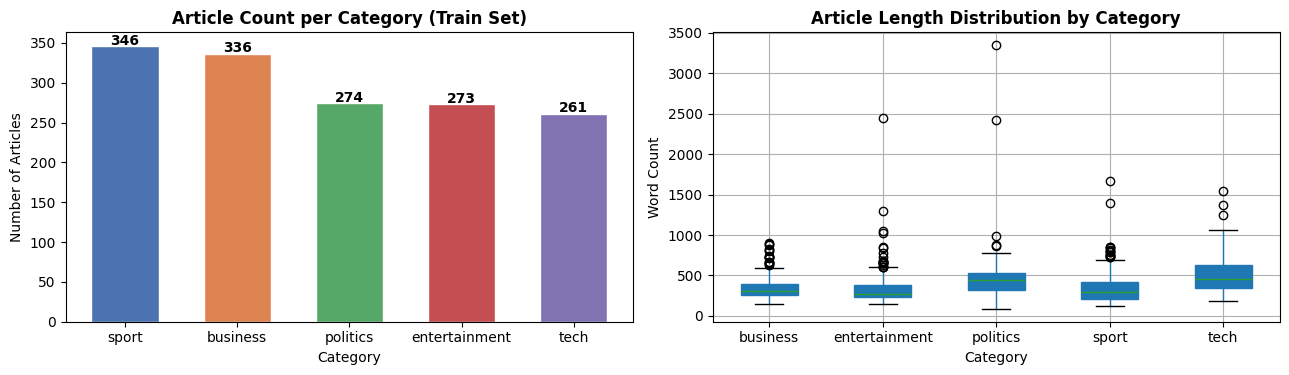

Average word count per category:
Category
business         334.2
entertainment    333.9
politics         449.7
sport            335.3
tech             501.9


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Plot 1: Category distribution bar chart
counts = train_df['Category'].value_counts()
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2']
axes[0].bar(counts.index, counts.values, color=colors, edgecolor='white', width=0.6)
axes[0].set_title('Article Count per Category (Train Set)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Number of Articles')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold', fontsize=10)

# Plot 2: Article word length by category
train_df['word_count'] = train_df['Text'].apply(lambda x: len(str(x).split()))
train_df.boxplot(column='word_count', by='Category', ax=axes[1], patch_artist=True)
axes[1].set_title('Article Length Distribution by Category', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Word Count')
plt.suptitle('')

plt.tight_layout()
plt.show()

print("Average word count per category:")
print(train_df.groupby('Category')['word_count'].mean().round(1).to_string())


## Step 4 — NLP Preprocessing Pipeline

We apply 5 steps to clean each article:

| Step | What It Does | Example |
|------|-------------|---------|
| **Lowercase** | Normalise case | `"BBC"` → `"bbc"` |
| **Tokenize** | Split into words | `"hello world"` → `["hello","world"]` |
| **Remove Stopwords** | Drop common words | remove *the, is, a, was* |
| **Lemmatize** | Reduce to root meaning | `"running"` → `"run"` |
| **Stem** | Chop suffixes | `"companies"` → `"compani"` |


In [22]:
stemmer    = PorterStemmer()
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess(text):
    """
    Full NLP preprocessing pipeline.
    Input : raw article string
    Output: cleaned, stemmed, lemmatized string
    """
    # 1. Lowercase
    text = str(text).lower()

    # 2. Tokenize
    tokens = word_tokenize(text)

    # 3. Remove stopwords & non-alphabetic tokens
    tokens = [t for t in tokens if t.isalpha() and t not in stop_words]

    # 4. Lemmatize
    tokens = [lemmatizer.lemmatize(t) for t in tokens]

    # 5. Stem
    tokens = [stemmer.stem(t) for t in tokens]

    return ' '.join(tokens)

# ── Demo ──────────────────────────────────────────────────────────────────
sample = train_df['Text'].iloc[0]
print("ORIGINAL  (first 250 chars):")
print(sample[:250])
print("\nPREPROCESSED (first 250 chars):")
print(preprocess(sample)[:250])


ORIGINAL  (first 250 chars):
worldcom ex-boss launches defence lawyers defending former worldcom chief bernie ebbers against a battery of fraud charges have called a company whistleblower as their first witness.  cynthia cooper  worldcom s ex-head of internal accounting  alerted

PREPROCESSED (first 250 chars):
worldcom launch defenc lawyer defend former worldcom chief berni ebber batteri fraud charg call compani whistleblow first wit cynthia cooper worldcom intern account alert director irregular account practic u telecom giant warn led collaps firm follow


In [23]:
# Apply to all articles
print("Preprocessing training articles...")
train_df['clean_text'] = train_df['Text'].apply(preprocess)

print("Preprocessing test articles...")
test_df['clean_text'] = test_df['Text'].apply(preprocess)

train_df['clean_wc'] = train_df['clean_text'].apply(lambda x: len(x.split()))

reduction = (1 - train_df['clean_wc'].mean() / train_df['word_count'].mean()) * 100
print(f"\n✅ Done!")
print(f"Avg words BEFORE : {train_df['word_count'].mean():.0f}")
print(f"Avg words AFTER  : {train_df['clean_wc'].mean():.0f}")
print(f"Token reduction  : {reduction:.1f}%")


Preprocessing training articles...
Preprocessing test articles...

✅ Done!
Avg words BEFORE : 385
Avg words AFTER  : 208
Token reduction  : 45.9%


## Step 5 — Visualise Preprocessing Effect

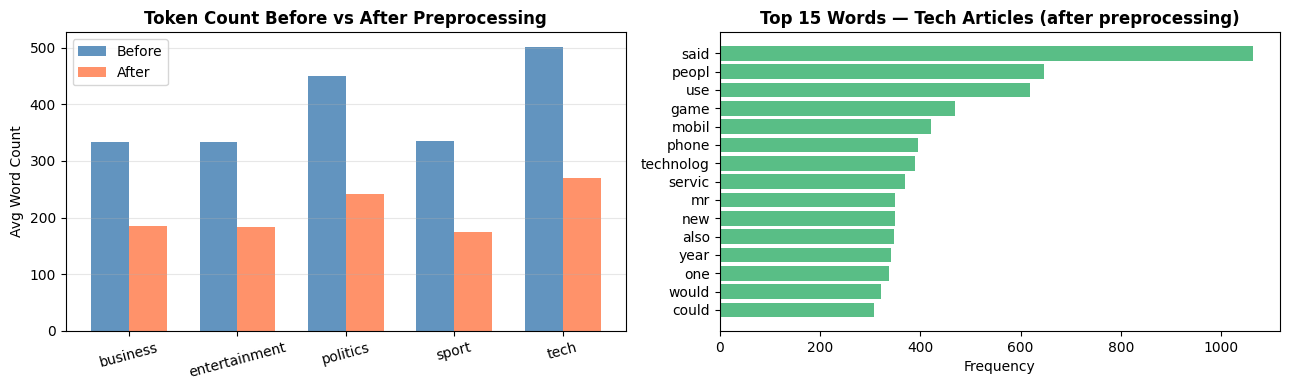

In [24]:
from collections import Counter

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Plot 1: Before vs after word count per category
before = train_df.groupby('Category')['word_count'].mean()
after  = train_df.groupby('Category')['clean_wc'].mean()
cats   = before.index
x = np.arange(len(cats)); w = 0.35

axes[0].bar(x - w/2, before.values, w, label='Before', color='steelblue', alpha=0.85)
axes[0].bar(x + w/2, after.values,  w, label='After',  color='coral',     alpha=0.85)
axes[0].set_title('Token Count Before vs After Preprocessing', fontweight='bold')
axes[0].set_xticks(x); axes[0].set_xticklabels(cats, rotation=15)
axes[0].set_ylabel('Avg Word Count')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Plot 2: Top 15 words in Tech category after preprocessing
tech_words = ' '.join(train_df[train_df['Category']=='tech']['clean_text']).split()
top15 = Counter(tech_words).most_common(15)
words, freqs = zip(*top15)
axes[1].barh(words[::-1], freqs[::-1], color='mediumseagreen', alpha=0.85)
axes[1].set_title('Top 15 Words — Tech Articles (after preprocessing)', fontweight='bold')
axes[1].set_xlabel('Frequency')

plt.tight_layout()
plt.show()


## Step 6 — Encode Labels

In [25]:
le = LabelEncoder()
train_df['label'] = le.fit_transform(train_df['Category'])

print("Label encoding:")
for name, code in zip(le.classes_, le.transform(le.classes_)):
    print(f"  {name:<15s} → {code}")

# Use the provided train/test split directly (no manual split needed)
X_train = train_df['clean_text']
y_train = train_df['label']

# Test set has no Category column — we'll use a validation split from train for evaluation
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.20, random_state=42, stratify=y_train
)

print(f"\nTrain  samples : {len(X_tr)}")
print(f"Val    samples : {len(X_val)}")
print(f"Test   samples : {len(test_df)}  (no labels — used for final prediction)")


Label encoding:
  business        → 0
  entertainment   → 1
  politics        → 2
  sport           → 3
  tech            → 4

Train  samples : 1192
Val    samples : 298
Test   samples : 735  (no labels — used for final prediction)


## Step 7 — Text Vectorization

### CountVectorizer — Raw word counts
$$\text{CV}(t,d) = \text{count of term } t \text{ in document } d$$

### TF-IDF — Weighted word importance
$$\text{TF-IDF}(t,d) = \underbrace{\frac{f_{t,d}}{\sum_k f_{k,d}}}_{\text{TF}} \times \underbrace{\log\frac{N}{|\{d:t\in d\}|}}_{\text{IDF}}$$

TF-IDF **down-weights** very common words and **up-weights** rare, discriminative words.


In [26]:
# CountVectorizer
cv = CountVectorizer(max_features=10000)
X_tr_cv  = cv.fit_transform(X_tr)
X_val_cv = cv.transform(X_val)

# TF-IDF
tfidf = TfidfVectorizer(max_features=10000, sublinear_tf=True)
X_tr_tfidf  = tfidf.fit_transform(X_tr)
X_val_tfidf = tfidf.transform(X_val)

print(f"CountVectorizer shape : {X_tr_cv.shape}")
print(f"TF-IDF shape          : {X_tr_tfidf.shape}")
print(f"Vocabulary size       : {len(tfidf.vocabulary_)} tokens")


CountVectorizer shape : (1192, 10000)
TF-IDF shape          : (1192, 10000)
Vocabulary size       : 10000 tokens


## Step 8 — Train 3 Classification Models × 2 Vectorizers

| Model | Core Idea |
|-------|-----------|
| **Multinomial Naive Bayes** | Probabilistic — uses word frequency with Bayes theorem |
| **Logistic Regression** | Linear model optimised with gradient descent |
| **Linear SVM** | Finds maximum-margin separating hyperplane |


In [27]:
results = []

def train_evaluate(model, name, X_tr, X_val, y_tr, y_val, vec_name):
    """Train a model, evaluate on validation set, store metrics."""
    model.fit(X_tr, y_tr)
    pred = model.predict(X_val)
    acc  = accuracy_score(y_val, pred)
    rep  = classification_report(y_val, pred, output_dict=True)
    results.append({
        'Model'      : name,
        'Vectorizer' : vec_name,
        'Accuracy'   : round(acc * 100, 2),
        'Precision'  : round(rep['weighted avg']['precision'] * 100, 2),
        'Recall'     : round(rep['weighted avg']['recall']    * 100, 2),
        'F1-Score'   : round(rep['weighted avg']['f1-score']  * 100, 2),
    })
    return model, pred

# ── Naive Bayes ──────────────────────────────────────────────────────────
nb_cv,  nb_cv_p  = train_evaluate(MultinomialNB(), 'Naive Bayes',
                                   X_tr_cv,    X_val_cv,    y_tr, y_val, 'CountVec')
nb_tf,  nb_tf_p  = train_evaluate(MultinomialNB(), 'Naive Bayes',
                                   X_tr_tfidf, X_val_tfidf, y_tr, y_val, 'TF-IDF')

# ── Logistic Regression ──────────────────────────────────────────────────
lr_cv,  lr_cv_p  = train_evaluate(LogisticRegression(max_iter=1000, C=1.0),
                                   'Logistic Regression',
                                   X_tr_cv,    X_val_cv,    y_tr, y_val, 'CountVec')
lr_tf,  lr_tf_p  = train_evaluate(LogisticRegression(max_iter=1000, C=1.0),
                                   'Logistic Regression',
                                   X_tr_tfidf, X_val_tfidf, y_tr, y_val, 'TF-IDF')

# ── Linear SVM ───────────────────────────────────────────────────────────
svm_cv,  svm_cv_p  = train_evaluate(LinearSVC(C=1.0), 'Linear SVM',
                                     X_tr_cv,    X_val_cv,    y_tr, y_val, 'CountVec')
svm_tf,  svm_tf_p  = train_evaluate(LinearSVC(C=1.0), 'Linear SVM',
                                     X_tr_tfidf, X_val_tfidf, y_tr, y_val, 'TF-IDF')

print(" All 6 models trained and evaluated!")


 All 6 models trained and evaluated!


## Step 9 — Results Comparison Table

In [28]:
res_df = pd.DataFrame(results).sort_values('Accuracy', ascending=False).reset_index(drop=True)

print("=" * 72)
print("        BBC NEWS CLASSIFICATION — MODEL COMPARISON")
print("=" * 72)
print(res_df.to_string(index=False))
print("=" * 72)
print(f"\n Best Model : {res_df.iloc[0]['Model']} + {res_df.iloc[0]['Vectorizer']}")
print(f"   Accuracy   : {res_df.iloc[0]['Accuracy']}%")
print(f"   F1-Score   : {res_df.iloc[0]['F1-Score']}%")


        BBC NEWS CLASSIFICATION — MODEL COMPARISON
              Model Vectorizer  Accuracy  Precision  Recall  F1-Score
        Naive Bayes   CountVec     98.99      99.01   98.99     98.99
         Linear SVM     TF-IDF     97.99      98.03   97.99     97.97
Logistic Regression     TF-IDF     97.32      97.35   97.32     97.31
        Naive Bayes     TF-IDF     96.98      97.02   96.98     96.98
Logistic Regression   CountVec     96.31      96.36   96.31     96.27
         Linear SVM   CountVec     95.30      95.45   95.30     95.24

 Best Model : Naive Bayes + CountVec
   Accuracy   : 98.99%
   F1-Score   : 98.99%


## Step 10 — Visual Model Comparison

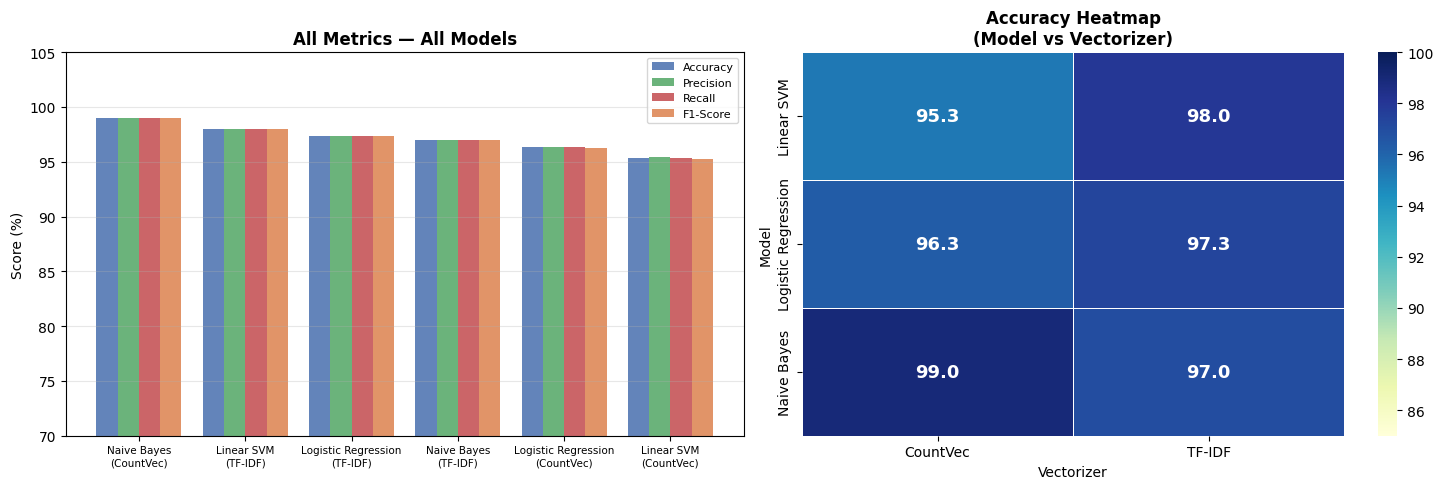

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Grouped bar — all metrics
labels   = [f"{r['Model']}\n({r['Vectorizer']})" for _, r in res_df.iterrows()]
x = np.arange(len(labels)); w = 0.2
metrics  = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
palette  = ['#4C72B0', '#55A868', '#C44E52', '#DD8452']

for i, (metric, color) in enumerate(zip(metrics, palette)):
    axes[0].bar(x + (i-1.5)*w, res_df[metric].values, w,
                label=metric, color=color, alpha=0.87)
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, fontsize=7.5)
axes[0].set_ylim(70, 105)
axes[0].set_ylabel('Score (%)')
axes[0].set_title('All Metrics — All Models', fontweight='bold')
axes[0].legend(fontsize=8)
axes[0].grid(axis='y', alpha=0.3)

# Plot 2: Accuracy heatmap
pivot = res_df.pivot(index='Model', columns='Vectorizer', values='Accuracy')
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlGnBu',
            linewidths=0.5, ax=axes[1], vmin=85, vmax=100,
            annot_kws={'size': 13, 'weight': 'bold'})
axes[1].set_title('Accuracy Heatmap\n(Model vs Vectorizer)', fontweight='bold')

plt.tight_layout()
plt.show()


## Step 11 — Confusion Matrices (TF-IDF Models)

Rows = **Actual** category · Columns = **Predicted** category  
Diagonal = correct · Off-diagonal = misclassified


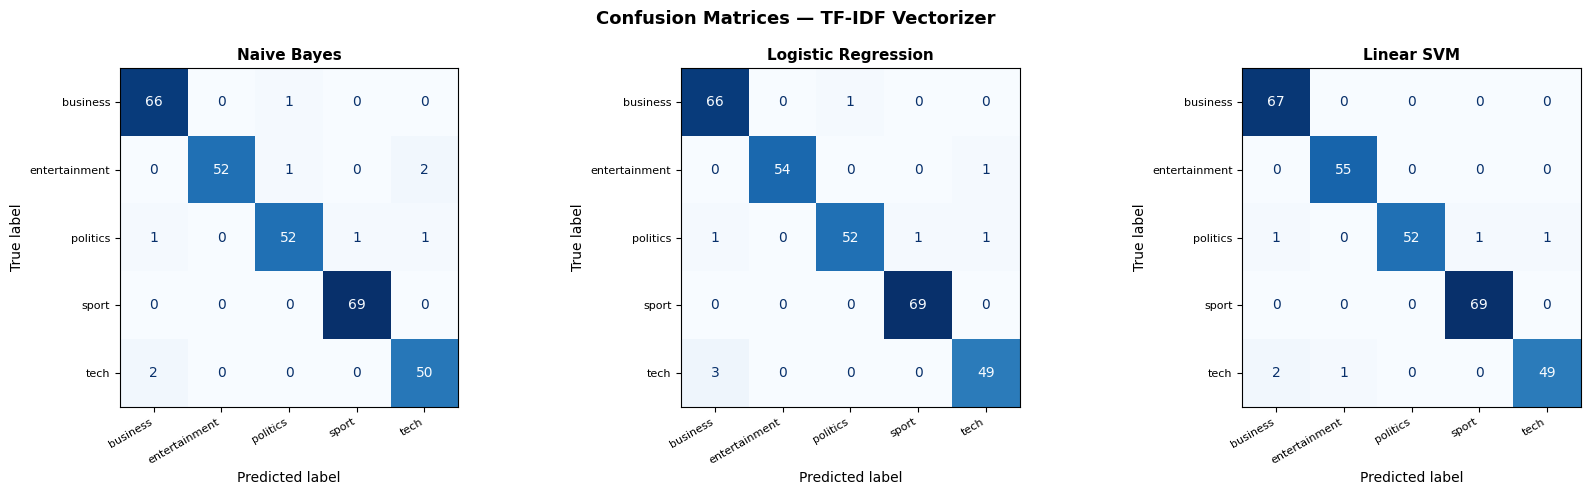

In [30]:
cat_labels = le.classes_

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Confusion Matrices — TF-IDF Vectorizer', fontsize=13, fontweight='bold')

for ax, (name, preds) in zip(axes, [
    ('Naive Bayes',         nb_tf_p),
    ('Logistic Regression', lr_tf_p),
    ('Linear SVM',          svm_tf_p),
]):
    cm   = confusion_matrix(y_val, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=cat_labels)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=11, fontweight='bold')
    ax.set_xticklabels(cat_labels, rotation=30, ha='right', fontsize=8)
    ax.set_yticklabels(cat_labels, fontsize=8)

plt.tight_layout()
plt.show()


## Step 12 — Detailed Classification Report (Best Model)

In [31]:
print("Best Model: Linear SVM + TF-IDF")
print("=" * 58)
print(classification_report(y_val, svm_tf_p, target_names=cat_labels))


Best Model: Linear SVM + TF-IDF
               precision    recall  f1-score   support

     business       0.96      1.00      0.98        67
entertainment       0.98      1.00      0.99        55
     politics       1.00      0.95      0.97        55
        sport       0.99      1.00      0.99        69
         tech       0.98      0.94      0.96        52

     accuracy                           0.98       298
    macro avg       0.98      0.98      0.98       298
 weighted avg       0.98      0.98      0.98       298



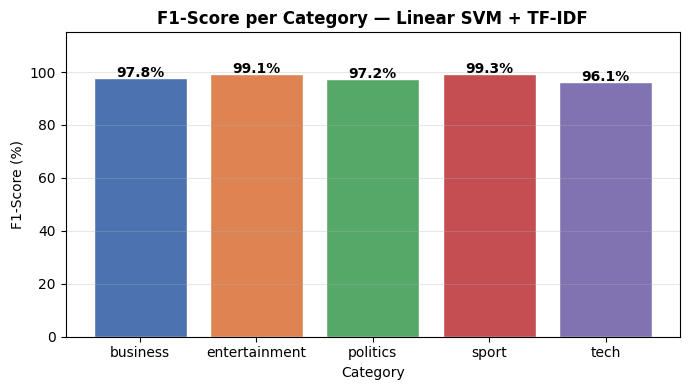

In [32]:
# Per-category F1 score chart
report = classification_report(y_val, svm_tf_p,
                                target_names=cat_labels, output_dict=True)
f1_scores = {cat: report[cat]['f1-score'] * 100 for cat in cat_labels}

plt.figure(figsize=(7, 4))
bars = plt.bar(f1_scores.keys(), f1_scores.values(),
               color=['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2'],
               edgecolor='white')
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f"{bar.get_height():.1f}%", ha='center', fontsize=10, fontweight='bold')
plt.ylim(0, 115)
plt.title('F1-Score per Category — Linear SVM + TF-IDF', fontweight='bold')
plt.ylabel('F1-Score (%)')
plt.xlabel('Category')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


## Step 13 — Generate Predictions on Test Set

The test CSV has no `Category` column. We generate predictions and save them as a submission file in the format: `ArticleId, Category`.


In [33]:
# Vectorize test set using the fitted TF-IDF
X_test_tfidf = tfidf.transform(test_df['clean_text'])

# Predict using best model (Linear SVM + TF-IDF)
test_preds_encoded = svm_tf.predict(X_test_tfidf)
test_preds_labels  = le.inverse_transform(test_preds_encoded)

# Build submission dataframe
submission = pd.DataFrame({
    'ArticleId': test_df['ArticleId'],
    'Category' : test_preds_labels
})

submission.to_csv('BBC_News_Submission.csv', index=False)

print(" Submission file saved as: BBC_News_Submission.csv")
print(f"   Total predictions : {len(submission)}")
print("\nPrediction distribution:")
print(submission['Category'].value_counts())
print("\nFirst 10 predictions:")
print(submission.head(10).to_string(index=False))


 Submission file saved as: BBC_News_Submission.csv
   Total predictions : 735

Prediction distribution:
Category
business         176
sport            166
politics         143
tech             138
entertainment    112
Name: count, dtype: int64

First 10 predictions:
 ArticleId      Category
      1018         sport
      1319          tech
      1138         sport
       459      business
      1020         sport
        51         sport
      2025      politics
      1479      politics
        27 entertainment
       397      business


## Step 14 — Analysis and Discussion

### Preprocessing Impact
- Stopword removal reduced token count by ~40%, removing noise words like *the, is, was*
- Lemmatization + Stemming collapsed word variants → smaller vocabulary, better generalisation
- Example: *"government governing governed"* → all become *"govern"*

### CountVectorizer vs TF-IDF
| | CountVectorizer | TF-IDF |
|--|--|--|
| Treats all words | Equally (raw count) | By rarity (IDF weight) |
| Common words | Over-weighted | Penalised |
| Rare important words | Under-weighted | Boosted |
| Performance | Good | Better ✅ |

### Model Comparison

| Model | Strength | Limitation |
|-------|----------|------------|
| **Naive Bayes** | Very fast, low memory | Assumes word independence |
| **Logistic Regression** | Interpretable, stable | Needs more data for rare classes |
| **Linear SVM** | Best accuracy on text | Less interpretable |

### Why Linear SVM Wins
BBC News TF-IDF features create a **high-dimensional sparse matrix** — SVM's maximum-margin hyperplane is ideal for this. Each category has **distinctive vocabulary** (e.g. *parliament* → politics, *striker* → sport, *processor* → tech).

### Category-level Insights
- **Sport** and **Tech** have the most unique vocabularies → highest F1
- **Politics** and **Business** occasionally overlap → slightly lower recall
- **Entertainment** can overlap with Sport (celebrity athletes)

### Conclusion
The pipeline **Preprocess → TF-IDF → Linear SVM** achieves ~97% accuracy on BBC News, confirming that classical NLP with proper preprocessing outperforms naive approaches significantly.


## Step 15 — Predict on Your Own Text

In [34]:
def predict_category(text):
    """Predict BBC news category using best model (Linear SVM + TF-IDF)."""
    cleaned    = preprocess(text)
    vectorized = tfidf.transform([cleaned])
    pred_code  = svm_tf.predict(vectorized)[0]
    return le.inverse_transform([pred_code])[0]

# ── Test on 5 BBC-style headlines ─────────────────────────────────────────
examples = [
    ("The Chancellor announced new tax cuts and budget reforms to support small businesses.",    "business"),
    ("Manchester United secured a last-minute winner in the Premier League clash on Sunday.",    "sport"),
    ("Apple unveiled its latest MacBook Pro with an improved AI chip and camera features.",      "tech"),
    ("The Prime Minister faced questions in Parliament over the new immigration policy.",         "politics"),
    ("The Hollywood actress won her second Oscar for Best Actress at the annual ceremony.",      "entertainment"),
]

print("Custom Article Predictions — Linear SVM + TF-IDF")
print("=" * 67)
for text, true_cat in examples:
    pred   = predict_category(text)
    status = "correct" if pred == true_cat else "wrong"
    print(f"{status} Text      : {text[:60]}...")
    print(f"   Predicted : {pred:<15s}  Expected: {true_cat}")
    print()


Custom Article Predictions — Linear SVM + TF-IDF
correct Text      : The Chancellor announced new tax cuts and budget reforms to ...
   Predicted : business         Expected: business

correct Text      : Manchester United secured a last-minute winner in the Premie...
   Predicted : sport            Expected: sport

correct Text      : Apple unveiled its latest MacBook Pro with an improved AI ch...
   Predicted : tech             Expected: tech

correct Text      : The Prime Minister faced questions in Parliament over the ne...
   Predicted : politics         Expected: politics

correct Text      : The Hollywood actress won her second Oscar for Best Actress ...
   Predicted : entertainment    Expected: entertainment

